미리보기 & 이미지 인식 시작하기

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

# sudo: switch user do : 관리자 권한
# apt-get install -y: 패키지를 자동으로 설치 (y 옵션으로 설치 확인 과정 생략)
# fonts-nanum*: 나눔 폰트 패키지들을 모두 설치 (*는 와일드카드)
# | tail -n 1: 설치 과정의 마지막 줄만 출력
# fc-cache: 폰트 캐시를 갱신하는 명령어
# -f: 강제로 캐시 재생성
# -v: 상세한 출력 표시
# matplotlib 라이브러리의 캐시 디렉토리를 완전히 삭제
# ~/.cache/matplotlib: 사용자 홈 디렉토리의 matplotlib 캐시 폴더
# -rf: 재귀적으로(-r) 강제로(-f) 삭제

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

라이브러리 & 커맨드 준비

In [2]:
!pip install torchviz | tail -n 1

w = !apt install tree

print(w[-2])

Setting up tree (2.0.2-1) ...


In [3]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()
# .get_name()
# FontProperties 객체에서 해당 폰트의 실제 폰트 이름을 반환

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [4]:
# warning 표시 끄기 (warn)
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [5]:
# gpu 디바이스 할당
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [ ]:
# 공통함수 읽어오기
# 공통함수 다운로드
!git clone https://github.com/wikibook/pythonlibs.git

from pythonlibs.torch_lib1 import *

# 공통함수 체크
print(README)

Cloning into 'pythonlibs'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 25 (delta 6), reused 25 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 21.10 MiB | 39.14 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Common Library for PyTorch
Author: M. Akaishi


In [7]:
%pwd
# present working directory(folder)

'/content'

학습 데이터 읽어오기

In [8]:
# 학습용 데이터 수집하기 (12장)

# 학습용 이미지 다운로드
w = !wget https://github.com/makaishi2/pythonlibs/raw/main/images/dog_wolf.zip
print(w[-2])

# 학습용 이미지 압축 풀기
w = !unzip dog_wolf.zip
print(w[-1])
# 디렉토리 설정
data_dir = 'dog_wolf'
#directory (win) folder

# 학습, 테스트 디렉토리명 설정
import os
train_dir = os.path.join(data_dir,'train')
test_dir = os.path.join(data_dir,'test')

# 분류 클래스 설정
classes = ['dog', 'wolf']


# 압축해제 결과 트리구조 보기
!tree dog_wolf

  inflating: dog_wolf/train/wolf/wolf-09.png  
dog_wolf
├── test
│   ├── dog
│   │   ├── dog-21.png
│   │   ├── dog-22.png
│   │   ├── dog-23.png
│   │   ├── dog-24.png
│   │   └── dog-25.png
│   └── wolf
│       ├── wolf-21.png
│       ├── wolf-22.png
│       ├── wolf-23.png
│       ├── wolf-24.png
│       └── wolf-25.png
└── train
    ├── dog
    │   ├── dog-01.png
    │   ├── dog-02.png
    │   ├── dog-03.png
    │   ├── dog-04.png
    │   ├── dog-05.png
    │   ├── dog-06.png
    │   ├── dog-07.png
    │   ├── dog-08.png
    │   ├── dog-09.png
    │   ├── dog-10.png
    │   ├── dog-11.png
    │   ├── dog-12.png
    │   ├── dog-13.png
    │   ├── dog-14.png
    │   ├── dog-15.png
    │   ├── dog-16.png
    │   ├── dog-17.png
    │   ├── dog-18.png
    │   ├── dog-19.png
    │   └── dog-20.png
    └── wolf
        ├── wolf-01.png
        ├── wolf-02.png
        ├── wolf-03.png
        ├── wolf-04.png
        ├── wolf-05.png
        ├── wolf-06.png
        ├── wolf-07.png
        ├── 

In [9]:
# transform 정의(**)

# 검증데이터용: 정규화만을 실시
test_transform = transforms.Compose([
     transforms.Resize(224),
     transforms.CenterCrop(224),
     transforms.ToTensor(),
     transforms.Normalize(0.5,0.5)
    ])

1. Compose는 "조립 라인"이에요
이미지가 컨베이어 벨트를 타고 이동하면서, 각 단계를 순서대로 통과한다고 생각하면 돼요. Resize → CenterCrop → ToTensor → Normalize 순서로 딱딱 처리됩니다.

2. Resize(224) — 비율은 유지한 채 작게
사진의 짧은 쪽 길이를 224로 맞춰요. 예를 들어 600×800 사진이면, 짧은 쪽(600)을 224로 줄이고, 긴 쪽은 비율에 맞게 자동으로 조정돼요 (224×299 정도가 됨). 사진이 찌그러지지 않아요.

3. CenterCrop(224) — 정사각형으로 딱 자르기
Resize만 하면 아직 정사각형이 아니에요 (224×299처럼 한쪽이 더 김). 그래서 가운데 부분만 224×224로 잘라내서 정사각형을 만들어요. 가장자리는 버려지는 거죠.

4. ToTensor() — 컴퓨터가 이해하는 숫자로 변환

원래 픽셀 값(0~255, 정수)을 0~1 사이의 소수로 바꿔요 (딥러닝 모델이 이 범위를 더 잘 다뤄요)
데이터 순서도 바꿔요: 원래는 (세로, 가로, 색상채널) 순서였는데, PyTorch가 좋아하는 (색상채널, 세로, 가로) 순서로 재배열

5. Normalize(0.5, 0.5) — 범위를 한 번 더 조정
0~1 범위를 -1~1로 옮겨요. 계산식은 (값 - 0.5) / 0.5예요. 예를 들어 0이면 (0-0.5)/0.5 = -1, 1이면 (1-0.5)/0.5 = 1이 됩니다. 딥러닝 모델은 보통 이렇게 0을 중심으로 대칭인 범위를 더 잘 학습해요.

ToTensor()를 거치면 채널이 맨 앞으로 오기 때문에, PyTorch 텐서의 실제 shape는 (3, 224, 224) — 즉 채널 3개, 세로 224, 가로 224 순서입니다. (224, 224, 3)은 numpy/PIL 이미지일 때의 순서예요.

In [10]:
# 학습데이터용: 정규화에 RandomHorizeontalFlip 과 RandomEraising 을 추가로 실시
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(0.5,0.5),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3,3.3), value=0, inplace=False)
])

코드 분석:
1. transforms.RandomHorizontalFlip(p=0.5)
- 50% 확률로 이미지를 좌우 반전
- 학습 데이터의 다양성을 증가시켜 과적합 방지
- 개/늑대 같은 동물 이미지에서 유용 (좌우 대칭성)

2. transforms.Resize(224), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize(0.5, 0.5)
- 검증용과 동일한 기본 전처리 과정
- 224x224 크기로 조정 후 [-1, 1] 범위로 정규화

3. transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
- 50% 확률로 이미지의 일부분을 임의로 지우기
- 매개변수 설명:
  - p=0.5: 50% 확률로 적용
  - scale=(0.02, 0.33): 지울 영역의 크기가 전체 이미지의 2%~33%
  - ratio=(0.3, 3.3): 지울 영역의 가로세로 비율이 0.3~3.3 범위
  - value=0: 지운 부분을 0으로 채움 (정규화 후이므로 회색)
  - inplace=False: 원본 텐서를 수정하지 않고 새로운 텐서 반환

- 데이터 증강의 효과:
  - RandomHorizontalFlip: 좌우 대칭 변형으로 데이터 2배 증가 효과
  - RandomErasing: 모델이 이미지의 특정 부분에만 의존하지 않도록 강제, 일반화 성능 향상
  - 이런 증강 기법들은 학습 시에만 적용하고, 검증/테스트 시에는 사용하지 않아 일관된 성능 평가를 보장

In [11]:
# dataset 정의
# 학습용 데이터셋: 데이터 등강이 적용된 train_transform 사용
# 폴더 구조 기반으로 자돌 라벨링 (폴더명리 클래스명)
train_data = datasets.ImageFolder(train_dir, transform=train_transform)


# 같은 학습 데이터지만 증강 없는 test_transform 사용
# 학습 데이터의 원본 성능 평가용
train_data2 = datasets.ImageFolder(train_dir, transform=test_transform)

# 테스트용 데이터셋: 증강 없는 test_transform 사용
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

# dataloader 정의
batch_size = 5

# train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
# 실제 학습용: 배치 크기 5, 데이터 섞음(랜덤 순서)
# 데이터 증강이 적용됨
train_loader = DataLoader(train_data, batch_size=5, shuffle=True)

# 학습 데이터 평가용 큰배치(40), 순서 고정
# 증강 없이 원본 상태로 평가
train_loader2 = DataLoader(train_data2, batch_size=40, shuffle=False)

# 테스트용: 작은 배치, 순서 고정
# 일관된 테스트 결과를 위해 shuffle=False
test_loader = DataLoader(test_data, batch_size=5, shuffle=False)

# 시각화/샘플링용: 중간 배치 크기, 랜덤 샘플링
# 다양한 테스트 샘플 확인용
test_loader2 = DataLoader(test_data, batch_size=10, shuffle=False)

학습 이미지 데이터 확인

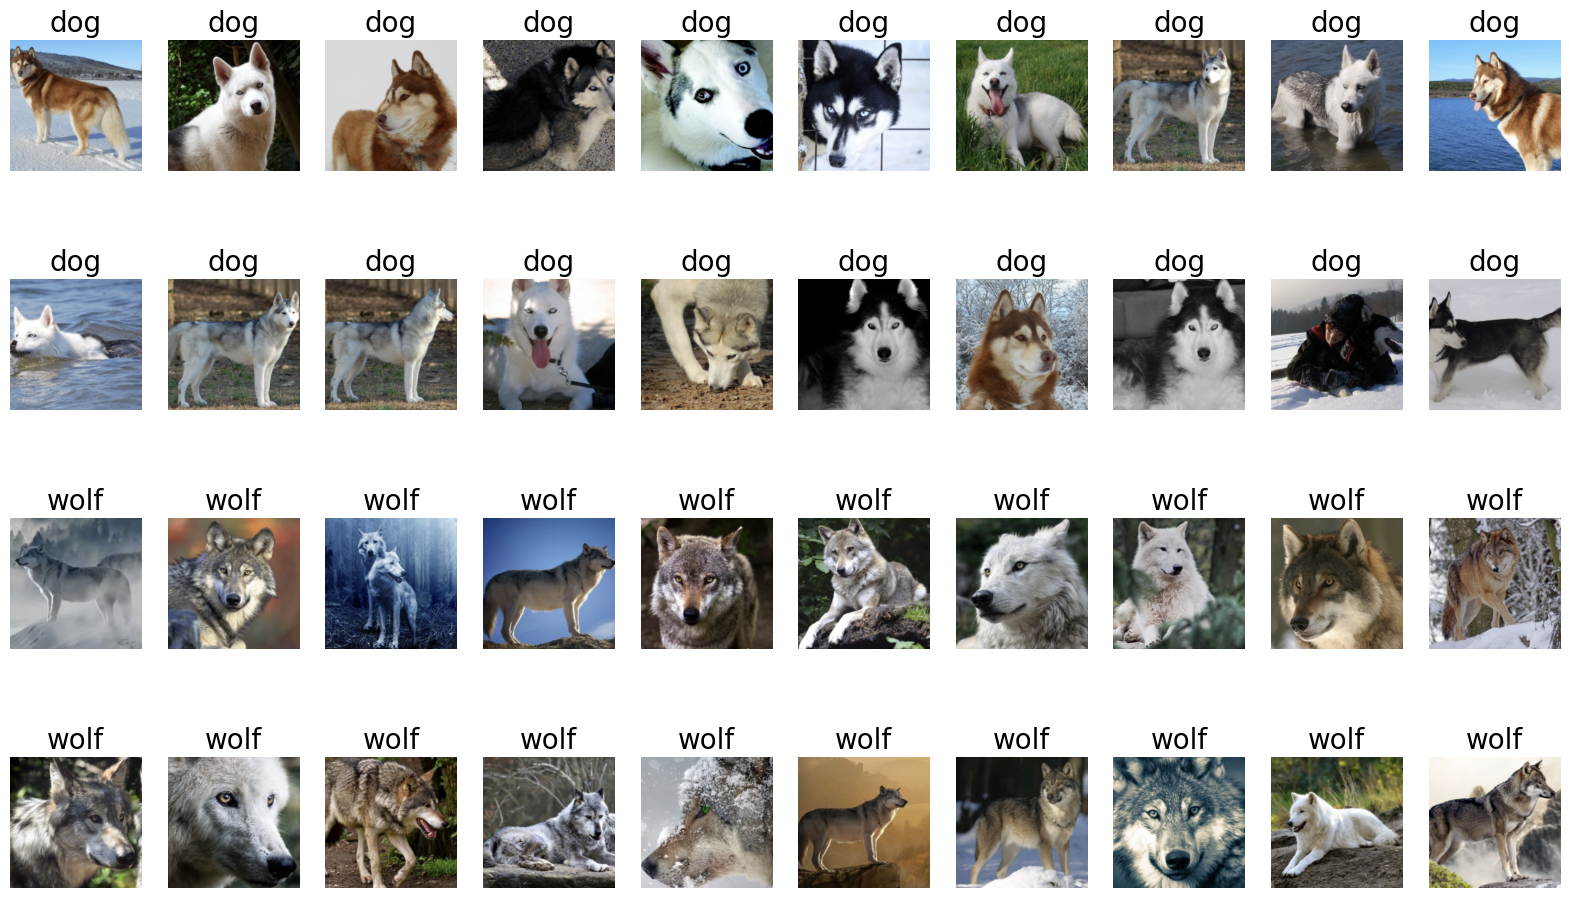

In [12]:
# https://github.com/wikibook/pythonlibs.git 에서 가져온 함수
show_images_labels(train_loader2, classes, None, None)

참고) 공통함수 내부 구조

In [13]:
# 학습용 함수
def fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history):

  base_epochs = len(history)

  for epoch in range(base_epochs, num_epochs+base_epochs):
    train_loss = 0
    train_acc = 0
    val_loss = 0
    val_acc = 0

    # 학습 페이즈
    net.train()
    count = 0

    for inputs, labels in tqdm(train_loader):
      count += len(labels)
      inputs = inputs.to(device)
      labels = labels.to(device)

      # 그라디언트 초기화
      optimizer.zero_grad()

      # 예측 계산
      outputs = net(inputs)

      # 손실 계산
      loss = criterion(outputs, labels)
      train_loss += loss.item()

      # 그라디언트 계산(역전파)
      loss.backward()

      # 파라미터 수정
      optimizer.step()

      # 예측 라벨 산출
      predicted = torch.max(outputs, 1)[1]

      # 정답을 맞춘 수 산출
      train_acc += (predicted == labels).sum()

      # 평균 손실값과 정확도 계산
      avg_train_loss = train_loss / count
      avg_train_acc = train_acc / count

    # 예측 페이즈
    net.eval()
    count = 0

    for inputs, labels in test_loader:
      count += len(labels)

      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = net(inputs)

      loss = criterion(outputs, labels)
      val_loss += loss.item()

      predicted = torch.max(outputs, 1)[1]

      val_acc += (predicted == labels).sum()

      avg_val_loss = val_loss / count
      avg_val_acc = val_acc / count

    print(f'Epoch [{epoch+1}/{num_epochs+base_epochs}], loss: {avg_train_loss}, acc: {avg_train_acc:.5f} val_loss: {avg_val_loss:.5f}, avg_val_acc: {avg_val_acc:.5f}')
    item = np.array([epoch+1, avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc])
    history = np.vstack((history, item))
  return history



In [14]:
# 이미지와 라벨 표시
def show_images_labels(loader, classes, net, device):

  for images, labels in loader:
    break

  n_size = min(len(images), 50)

  if net is not None:
    inputs = images.to(device)
    labels = labels.to(device)

    outputs = net(inputs)
    predicted = torch.max(outputs,1)[1]


  plt.figure(figsize=(20, 15))
  for i in range(n_size):
    ax = plt.subplot(5,10,i+1)
    label_name = classes[labels[i]]

    if net is not None:
      predicted_name = classes[predicted[i]]

      if label_name == predicted_name:
        c = 'k'
      else:
        c = 'b'
      ax.set_title(label_name+':'+predicted_name, c=c, fontsize=20)

    else:
      ax.set_title(label_name, fontsize=20)

    image_np = images[i].numpy().copy()
    img = np.transpose(image_np, (1,2,0))
    img = (img + 1)/2
    plt.imgshow()
    ax.set_axis_off()
  plt.show()

In [15]:
# 파이토치 난수 고정

def torch_seed(seed=123):
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.use_determainistic_algorithms = True